In [ ]:
import numpy as np
import matplotlib.pyplot as plt

**CART**

In [ ]:
def entropy(y):
  classes, count = np.unique(y, return_counts = True)
  probs = count/len(y)
  return -np.sum(probs*np.log2(probs+1e-9))

In [ ]:
def information_gain(y, left_y, right_y):
  l = len(y)
  weighted = (len(left_y)/l)*entropy(left_y) + (len(right_y)/l)*entropy(right_y)
  return entropy(y) - weighted

In [ ]:
# Test entropy
print(entropy(np.array([0,0,0,0])))     # should be 0.0 — pure node
print(entropy(np.array([0,1,0,1])))     # should be 1.0 — max impurity
print(entropy(np.array([0,0,1,1,1])))   # should be ~0.971

# Test information gain
y = np.array([0,0,1,1,1,1])
left = np.array([0,0])
right = np.array([1,1,1,1])
print(information_gain(y, left, right))  # should be high, close to parent entropy

-1.4426951595367387e-09
0.99999999711461
0.9709505915692787
0.9182958326117947


In [ ]:
#In this function scan every possible feature, to find out the one having having the best IG, and return that best feature and best threshold for splitting
def best_split(X, y):
  best_ig = -1
  best_feature, best_threshold = None, None
  for feature in range(X.shape[1]): #the np.of feature is the column of X.shape vector
    thresholds = np.unique(X[:,feature])
    for threshold in thresholds:
      left_mask = X[:,feature] <= threshold
      right_mask = ~left_mask
      if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
        continue
      info_gain = information_gain(y, y[left_mask], y[right_mask]) #go to the nodes which are true
      if best_ig < info_gain:
        best_ig = info_gain
        best_feature = feature
        best_threshold = threshold
  return best_feature, best_threshold

In [ ]:
# Simple test — known data, predictable best split
X_test = np.array([[1, 2],
                   [2, 3],
                   [8, 9],
                   [9, 10]])
y_test = np.array([0, 0, 1, 1])

feature, threshold = best_split(X_test, y_test)
print(f"Best feature: {feature}, Best threshold: {threshold}")
# Expected: feature 0 or 1 (both separate cleanly), threshold between 2-8 or 3-9

Best feature: 0, Best threshold: 2


In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
feature, threshold = best_split(X, y)
print(f"Best feature: {feature}, Best threshold: {threshold:.4f}")

Best feature: 1, Best threshold: -0.0259


In [ ]:
class Node:
  def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.value = value

def build_tree(X, y, max_depth=None, depth=0):
  if entropy(y) == 0:
    return Node(value = y[0])
  if len(y) == 0:
    return Node(value=0)
  if max_depth is not None and depth >= max_depth:
    return Node(value=np.bincount(y).argmax())

  feature, threshold = best_split(X,y)
  if feature is None:
    return Node(value = np.bincount(y).argmax())
  left_mask = X[:, feature] <= threshold
  right_mask = ~left_mask

  left = build_tree(X[left_mask], y[left_mask], max_depth, depth+1)
  right = build_tree(X[right_mask], y[right_mask], max_depth, depth +1)

  return Node(feature=feature, threshold=threshold, left=left, right=right)



***TESTER***

In [ ]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
tree = build_tree(X, y, max_depth=3)
print(tree.feature, tree.threshold)  # should print the root split

1 -0.025902852911514507


In [ ]:
def predict_sample(node, x):
  if node.value is not None:
    return node.value
  if x[node.feature] <= node.threshold:
    return predict_sample(node.left, x)
  else:
    return predict_sample(node.right, x)

def predict(node, X):
  return np.array([predict_sample(node, x) for x in X])

In [ ]:
preds = predict(tree, X)
accuracy = np.mean(preds == y) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 90.33%


In [ ]:
tree_full = build_tree(X, y, max_depth=None)
preds_full = predict(tree_full, X)
print(f"Accuracy (no depth limit): {np.mean(preds_full == y) * 100:.2f}%")

Accuracy (no depth limit): 100.00%


In [ ]:
for depth in [1,2, 3,4,9, None]:
  tree_full = build_tree(X, y, max_depth=depth)
  preds_full = predict(tree_full,X)
  print(f"Accuracy at {depth}: {np.mean(preds_full==y)*100:.2f}%")

Accuracy at 1: 81.33%
Accuracy at 2: 90.33%
Accuracy at 3: 90.33%
Accuracy at 4: 90.67%
Accuracy at 9: 99.00%
Accuracy at None: 100.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, tree, title="Decision Boundary"):
    # 1. Find x and y axis min/max with 0.5 padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 2. Create meshgrid with 0.01 step
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # 3. Create grid of points — shape (n_points, 2)
    # 4. Predict on grid
    # np.c_ concatenates the flattened arrays into coordinate pairs
    Z = predict(np.c_[xx.ravel(), yy.ravel()])

    # 5. Reshape predictions to meshgrid shape
    Z = Z.reshape(xx.shape)

    # 6. Plot contourf (filled background), contour (lines), and scatter (data points)
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu') # Background colors
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolor='k', s=40) # Actual data

    # 7. Add title and show
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show() # <--- This is the "Print" command for plots

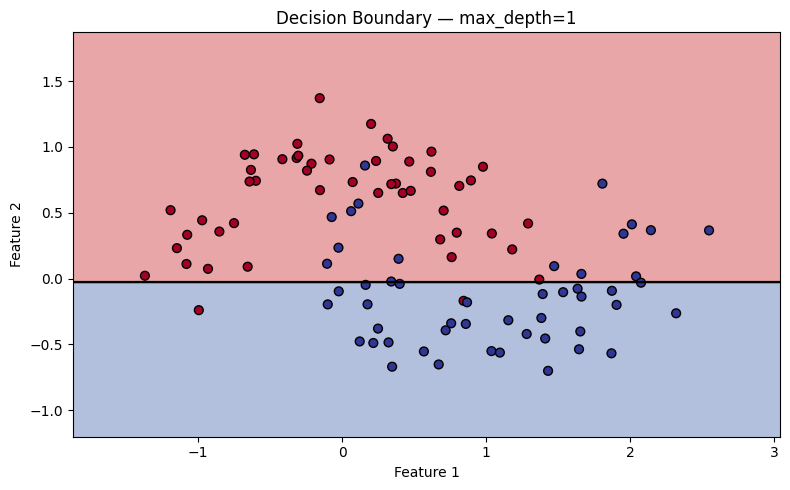

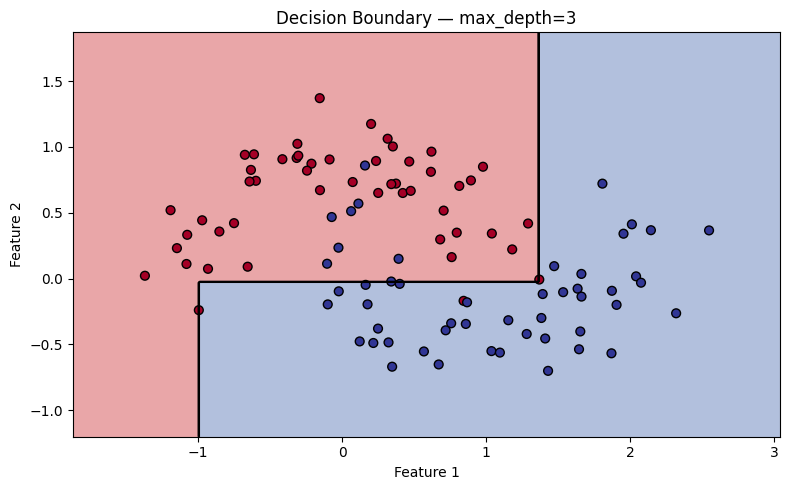

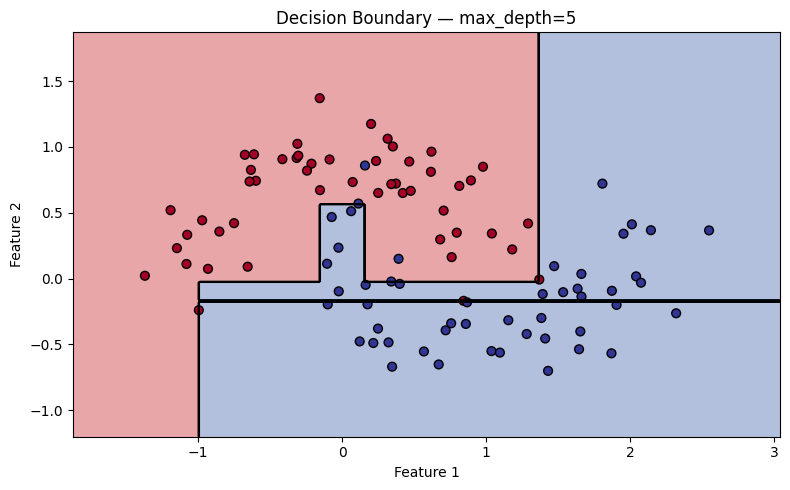

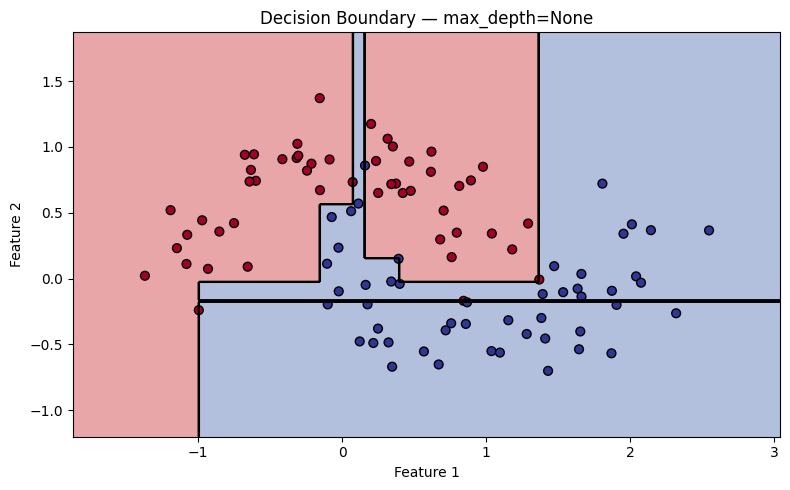

In [ ]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, tree, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()]  # shape (n_points, 2)
    Z = predict(tree, grid)               # your predict function
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    plt.contour(xx, yy, Z, colors='k', linewidths=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=40)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# Plot for each depth
for depth in [1, 3, 5, None]:
    tree = build_tree(X, y, max_depth=depth)
    plot_decision_boundary(X, y, tree, title=f"Decision Boundary — max_depth={depth}")